# Option 2: Open Research Question

### Introduction:
*How does propagation strength decrease with graph distance? Does the decay differ in WT vs mutants?*

The biological motivation behind the idea is to test how propagation strength changes with neighbour distance and it may reveal whether mutant cell lines exhibit broader or more persistent spatial coordination compared to WT cells.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
from collections import deque
import numpy as np
import subprocess

PROJECT_ROOT  = Path('/Users/zofiarewak/Desktop/BiolSys/UW-SysBiol-Project2/')
SCRIPTS_DIR = PROJECT_ROOT / 'data/spatiotemporal-continuation/scripts'
DATA_PATH    = PROJECT_ROOT / 'data/spatiotemporal-continuation/single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = SCRIPTS_DIR / '../01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = SCRIPTS_DIR / 'outputs'

EXP_ID = 1
SIGNAL_COL = 'ERKKTR_ratio'
MAX_LAG = 6

MUTATIONS_SITES = {
    "WT": 1,
    "AKT1_E17K": 5, 
    "PTEN_del": 17
}


In [2]:
processes = []
for site_id in MUTATIONS_SITES.values():
    print(f"Running analysis for site {site_id}...")
    cmd = [
        sys.executable,
        str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path', str(DATA_PATH),
        '--meta-path', str(META_PATH),
        '--exp-id', str(EXP_ID),
        '--site-id', str(site_id),
        '--signal-col', SIGNAL_COL,
        '--output-dir', str(OUTPUT_ROOT),
    ]
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    processes.append((site_id, p))

for site_id, p in processes:
    stdout, stderr = p.communicate()
    if p.returncode == 0:
        print(f"Site {site_id} processed successfully.")
    else:
        print(f"Error in site {site_id}: {stderr}")

Running analysis for site 1...
Running analysis for site 5...
Running analysis for site 17...
Site 1 processed successfully.
Site 5 processed successfully.
Site 17 processed successfully.


Immediate neighbours correspond to graph distance 1.
Second-degree neighbours correspond to neighbours-of-neighbours.
We test how does future self-jump probability decay at larger graph distances. 

In [3]:
def build_graph(edges):
    graph = defaultdict(set)

    for _, row in edges.iterrows():
        a = row["source_node_id"] 
        b = row["target_node_id"]

        graph[a].add(b) #building graph based on source nodes and target nodes
        graph[b].add(a)

    return graph

In [4]:
from collections import defaultdict, deque

def compute_distances(graph, max_distance=3):
    all_distances = {} #a dict containing all distances between nodes in a graph


    for node in graph.keys():

        visited = {node}
        current = {node}

        distances = defaultdict(set)

        for d in range(1, max_distance + 1):

            nxt = set()

            for n in current:
                nxt.update(graph[n])

            nxt = nxt - visited

            distances[d] = nxt
            visited.update(nxt)
            current = nxt

        all_distances[node] = distances

    return all_distances

In [5]:
def compute_rr_by_distance(nodes, graph, distances_map, max_distance=3):

    # jump_event- does the node jump now?
    # future_self_jump- will the node jump in the future?
    node_lookup = nodes.set_index("node_id")[["jump_event", "future_self_jump"]]

    # store final RR results for each graph distance
    results = []

    jump_set = set(node_lookup.index[node_lookup["jump_event"]])

    for d in range(1, max_distance + 1):
        
        # nodes exposed to at least one jumping neighbour
        exposed = [] 
        unexposed = []

        for node_id in node_lookup.index:

            #skipping missing nodes 
            if node_id not in distances_map:
                continue
        
            neighbours_d = distances_map[node_id][d]

            #skipping nodes without neighbours
            if len(neighbours_d) == 0:
                continue

            is_exposed = len(neighbours_d & jump_set) > 0

            future_jump = node_lookup.loc[node_id, "future_self_jump"]

            if is_exposed:
                exposed.append(future_jump)
            else:
                unexposed.append(future_jump)
        
        # probability of future jump among exposed and unexposed nodes
        p_exp = np.mean(exposed) if exposed else np.nan
        p_unexp = np.mean(unexposed) if unexposed else np.nan

        rr = p_exp / p_unexp if p_unexp > 0 else np.nan

        results.append({
            "distance": d,
            "RR": rr,
            "p_exp": p_exp,
            "p_unexp": p_unexp,
            "n_exp": len(exposed),
            "n_unexp": len(unexposed)
        })

    return pd.DataFrame(results)

In [6]:
def load_site(site_id):
    path = OUTPUT_ROOT / f"exp_1_site_{site_id}_ERKKTR_ratio"

    nodes = pd.read_csv(f"{path}/nodes.csv.gz")
    edges = pd.read_csv(f"{path}/spatial_edges.csv.gz")

    return nodes, edges


In [7]:
results = {}
print("Computing decay...")
for mut, site in MUTATIONS_SITES.items():

    # nodes and egdes per site 
    nodes, edges = load_site(site)

    # building graph, computing distances and rr by distance for each site
    graph = build_graph(edges)
    distances_map = compute_distances(graph, max_distance=3)
    # computing decay
    rr_df = compute_rr_by_distance(nodes, graph,distances_map, max_distance=3)

    results[mut] = rr_df
    print(f"Computing decay for site {site} complete")

Computing decay...
Computing decay for site 1 complete
Computing decay for site 5 complete
Computing decay for site 17 complete


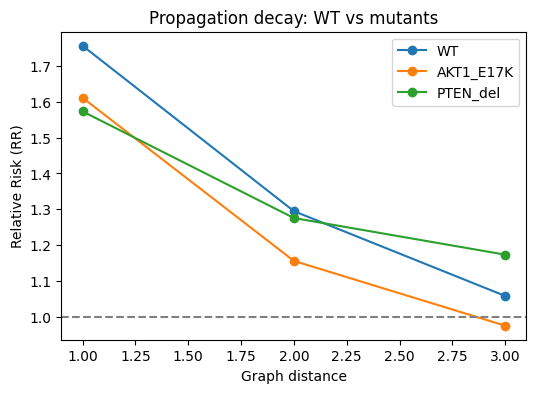

In [8]:
plt.figure(figsize=(6,4))

for mut, df in results.items():
    plt.plot(df["distance"], df["RR"], marker="o", label=mut)

plt.axhline(1, color="gray", linestyle="--")
plt.xlabel("Graph distance")
plt.ylabel("Relative Risk (RR)")
plt.title("Propagation decay: WT vs mutants")
plt.legend()
plt.show()